In [53]:
import sys
from pathlib import Path

# path_to_your_local_folder = Path("/Users/marco/Work-MBP/gtfs_railways")
path_to_your_local_folder = Path("C:/Users/KIIT/Documents/UAntwerp/railways_resilience")
sys.path.append(str(path_to_your_local_folder))

from utils.imports import *

In [54]:
from config import PATH_TO_SQLITE
attributes = load_gtfs(str(PATH_TO_SQLITE))
L_graph = load_graph(L_SPACE_PATH)
P_graph = load_graph(P_SPACE_PATH)

## Main

In [3]:
subgraph = load_graph(DATA_DIR / "pkl" / "belgium" / "patterns" / "star" / "graph_0.pkl")
plot_graph(subgraph, back_map="OSM")

In [4]:
import copy

def simulate_fixed_node_removal_efficiency(
    L_graph,
    sp_func,
    num_to_remove=None,
    pct_to_remove=None,  # priority over num_to_remove
    method='random',  # random, targeted, betweenness, hubs, or custom
    removal_type='node',
    custom_nodes=None,  # list of nodes to remove in order (only for method='custom')
    seed=None,
    verbose=False
):
    """
    Simulates the impact of sequential removals (node or edge) on global efficiency.

    Parameters:
        L_graph (networkx.Graph): The subgraph from which nodes/edges will be removed.
        num_to_remove (int, optional): Number of elements to remove. Ignored if percentage is given.
        pct_to_remove (int, optional): Percentage of elements to remove (1-100).
        method (str): Removal method. Options:
            'random', 'targeted', 'betweenness',
            'top_hubs_edges', 'top_hubs_trains',
            'custom' (requires custom_nodes).
        removal_type (str): 'node' or 'edge'.
        custom_nodes (list, optional): List of nodes to remove in given order (used if method='custom').
        seed (int, optional): Random seed.
        verbose (bool): Print progress/debug info.
    """
    G = copy.deepcopy(L_graph)

    if removal_type == "node":
        total_elements = G.number_of_nodes()
    elif removal_type == "edge":
        total_elements = G.number_of_edges()
    else:
        raise ValueError("Invalid removal_type. Choose 'node' or 'edge'.")

    if method != "custom":  # normal modes
        if pct_to_remove is not None:
            if not (1 <= pct_to_remove <= 100):
                raise ValueError("Percentage must be between 1 and 100.")
            num_to_remove = int(total_elements * (pct_to_remove / 100))
        elif num_to_remove is None:
            raise ValueError("Specify num_to_remove or pct_to_remove.")

        if num_to_remove > total_elements:
            if verbose:
                print(f"Adjusting number of elements to remove from {num_to_remove} to {total_elements - 2}.")
            num_to_remove = max(total_elements - 2, 1)

    # Node removals
    if removal_type == "node":
        if method == "random":
            return random_node_removal(L_graph, G, num_to_remove, sp_func, seed, verbose)
        elif method == "random_average":
            return random_node_removal_average(L_graph, G, num_to_remove, sp_func, verbose)
        elif method == "targeted":
            return targeted_node_removal(L_graph, G, num_to_remove, sp_func, verbose)
        elif method == "targeted_least":
            return targeted_node_removal_least(L_graph, G, num_to_remove, sp_func, verbose)
        elif method == "betweenness_weighted":
            return betweenness_node_removal_weighted(L_graph, G, num_to_remove, sp_func, verbose)
        elif method == "betweenness_unweighted":
            return betweenness_node_removal_unweighted(L_graph, G, num_to_remove, sp_func, verbose)
        elif method == "betweenness_weighted_least":
            return betweenness_node_removal_weighted_least(L_graph, G, num_to_remove, sp_func, verbose)
        elif method == "betweenness_unweighted_least":
            return betweenness_node_removal_unweighted_least(L_graph, G, num_to_remove, sp_func, verbose)
        elif method == "top_hubs_edges":
            return top_hubs_node_removal(L_graph, G, num_to_remove, sp_func, verbose)
        elif method == "top_hubs_trains":
            return top_train_hubs_node_removal(L_graph, G, num_to_remove, sp_func, verbose)
        elif method == "custom":
            if not custom_nodes:
                raise ValueError("Provide a list of custom_nodes when using method='custom'.")
            return custom_node_removal(L_graph, G, custom_nodes, sp_func, verbose)
        else:
            raise ValueError("Invalid method.")
    
    # Edge removals
    elif removal_type == "edge":
        if method == "random":
            return random_edge_removal(L_graph, G, num_to_remove, sp_func, seed, verbose)
        elif method == "random_average":
            return random_edge_removal_average(L_graph, G, num_to_remove, sp_func, verbose)
        elif method == "targeted":
            return targeted_edge_removal(L_graph, G, num_to_remove, sp_func, verbose)
        elif method == "targeted_least":
            return targeted_edge_removal_least(L_graph, G, num_to_remove, sp_func, verbose)
        elif method == "betweenness_weighted":
            return betweenness_edge_removal_weighted(L_graph, G, num_to_remove, sp_func, verbose)
        elif method == "betweenness_unweighted":
            return betweenness_edge_removal_unweighted(L_graph, G, num_to_remove, sp_func, verbose)
        elif method == "betweenness_weighted_least":
            return betweenness_edge_removal_weighted_least(L_graph, G, num_to_remove, sp_func, verbose)
        elif method == "betweenness_unweighted_least":
            return betweenness_edge_removal_unweighted_least(L_graph, G, num_to_remove, sp_func, verbose)

        else:
            raise ValueError("Invalid method for edge removal.")
    
    return None

simulate_fixed_node_removal_efficiency = compute_time(simulate_fixed_node_removal_efficiency) # time decorator
random_node_removal_average = compute_time(random_node_removal_average) # time decorator
random_edge_removal_average = compute_time(random_edge_removal_average) # time decorator

In [5]:
# # Simulation for a single graph
# sp_func = make_sp_func(attributes, get_all_GTC_v4, P_space_v4)

# original_efficiency, efficiencies, pct_remaining, removed_nodes, removal_times = \
#     simulate_fixed_node_removal_efficiency(
#         L_graph=subgraph,
#         sp_func=sp_func,
#         pct_to_remove=100,
#         removal_type='node',
#         method='betweenness_unweighted',
#         seed=2906597030,
#         verbose=True
#     )

# # Plot normalized efficiency vs number of nodes removed
# plot_efficiency_results(pct_remaining, efficiencies)

In [6]:
import matplotlib.pyplot as plt
import copy

def plot_all_removal_strategies(subgraph, attributes, get_all_GTC_v4, P_space_v4, n_runs=10):
    """
    Run multiple removal strategies and generate 10 separate plots in a 2x5 grid.
    Random removal plots now show mean ± standard deviation shading.
    """

    sp_func = make_sp_func(attributes, get_all_GTC_v4, P_space_v4)

    # Define all strategies in the required order
    strategies = [
        ("Random Node (Average)", "node", "random_average"),
        ("Random Edge (Average)", "edge", "random_average"),
        ("Targeted Node", "node", "targeted"),
        ("Targeted Edge", "edge", "targeted"),
        ("Betweenness Centrality (Unweighted)", "node", "betweenness_unweighted"),
        ("Betweenness Centrality (Weighted)", "node", "betweenness_weighted"),
        ("Targeted Node (Least)", "node", "targeted_least"),
        ("Targeted Edge (Least)", "edge", "targeted_least"),
        ("Betweenness Centrality (Unweighted Least)", "node", "betweenness_unweighted_least"),
        ("Betweenness Centrality (Weighted Least)", "node", "betweenness_weighted_least")
    ]

    results = {}

    # Run all strategies
    for label, rtype, method in strategies:
        print(f"=== Running: {label} ===")

        if method == "random_average":
            if rtype == "node":
                orig, mean_eff, std_eff, pct = random_node_removal_average(
                    L_graph=subgraph,
                    G=subgraph.copy(),
                    num_to_remove=subgraph.number_of_nodes(),
                    sp_func=sp_func,
                    n_runs=n_runs,
                    verbose=False
                )
            else:
                orig, mean_eff, std_eff, pct = random_edge_removal_average(
                    L_graph=subgraph,
                    G=subgraph.copy(),
                    num_to_remove=subgraph.number_of_edges(),
                    sp_func=sp_func,
                    n_runs=n_runs,
                    verbose=False
                )
            results[label] = (pct, mean_eff, std_eff)

        else:
            orig, effs, pct, removed, times = simulate_fixed_node_removal_efficiency(
                L_graph=subgraph,
                sp_func=sp_func,
                pct_to_remove=100,
                removal_type=rtype,
                method=method,
                seed=42,
                verbose=False
            )
            results[label] = (pct, effs)

    # Plot in 2x5 grid
    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.flatten()

    for i, (label, data) in enumerate(results.items()):
        ax = axes[i]

        if "Random" in label:
            pct, mean_eff, std_eff = data
            ax.plot(pct, mean_eff, marker='o', color='tab:blue', label="Mean Efficiency", markersize=3)
            ax.fill_between(pct, mean_eff - std_eff, mean_eff + std_eff, color='gray', alpha=0.3, label="Std Deviation")
        else:
            pct, effs = data
            ax.plot(pct, effs, marker='o', color='tab:red', label="Efficiency", markersize=3)

        ax.set_xlabel(f"% of {label.split()[1]}s Remaining")
        ax.set_ylabel("Normalized Efficiency")
        ax.set_title(label, fontsize=10)
        ax.invert_xaxis()
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(fontsize=8)

    # Remove any unused subplots (if fewer than 10)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

    return results


=== Running: Random Node (Average) ===
Function 'random_node_removal_average' completed.
Execution time: 2.73 seconds

=== Running: Random Edge (Average) ===
Function 'random_edge_removal_average' completed.
Execution time: 4.32 seconds

=== Running: Targeted Node ===
Function 'simulate_fixed_node_removal_efficiency' completed.
Execution time: 1.90 seconds

=== Running: Targeted Edge ===
Function 'simulate_fixed_node_removal_efficiency' completed.
Execution time: 4.90 seconds

=== Running: Betweenness Centrality (Unweighted) ===
Function 'simulate_fixed_node_removal_efficiency' completed.
Execution time: 0.20 seconds

=== Running: Betweenness Centrality (Weighted) ===
Function 'simulate_fixed_node_removal_efficiency' completed.
Execution time: 0.18 seconds

=== Running: Targeted Node (Least) ===
Function 'simulate_fixed_node_removal_efficiency' completed.
Execution time: 5.93 seconds

=== Running: Targeted Edge (Least) ===
Function 'simulate_fixed_node_removal_efficiency' completed.
Ex

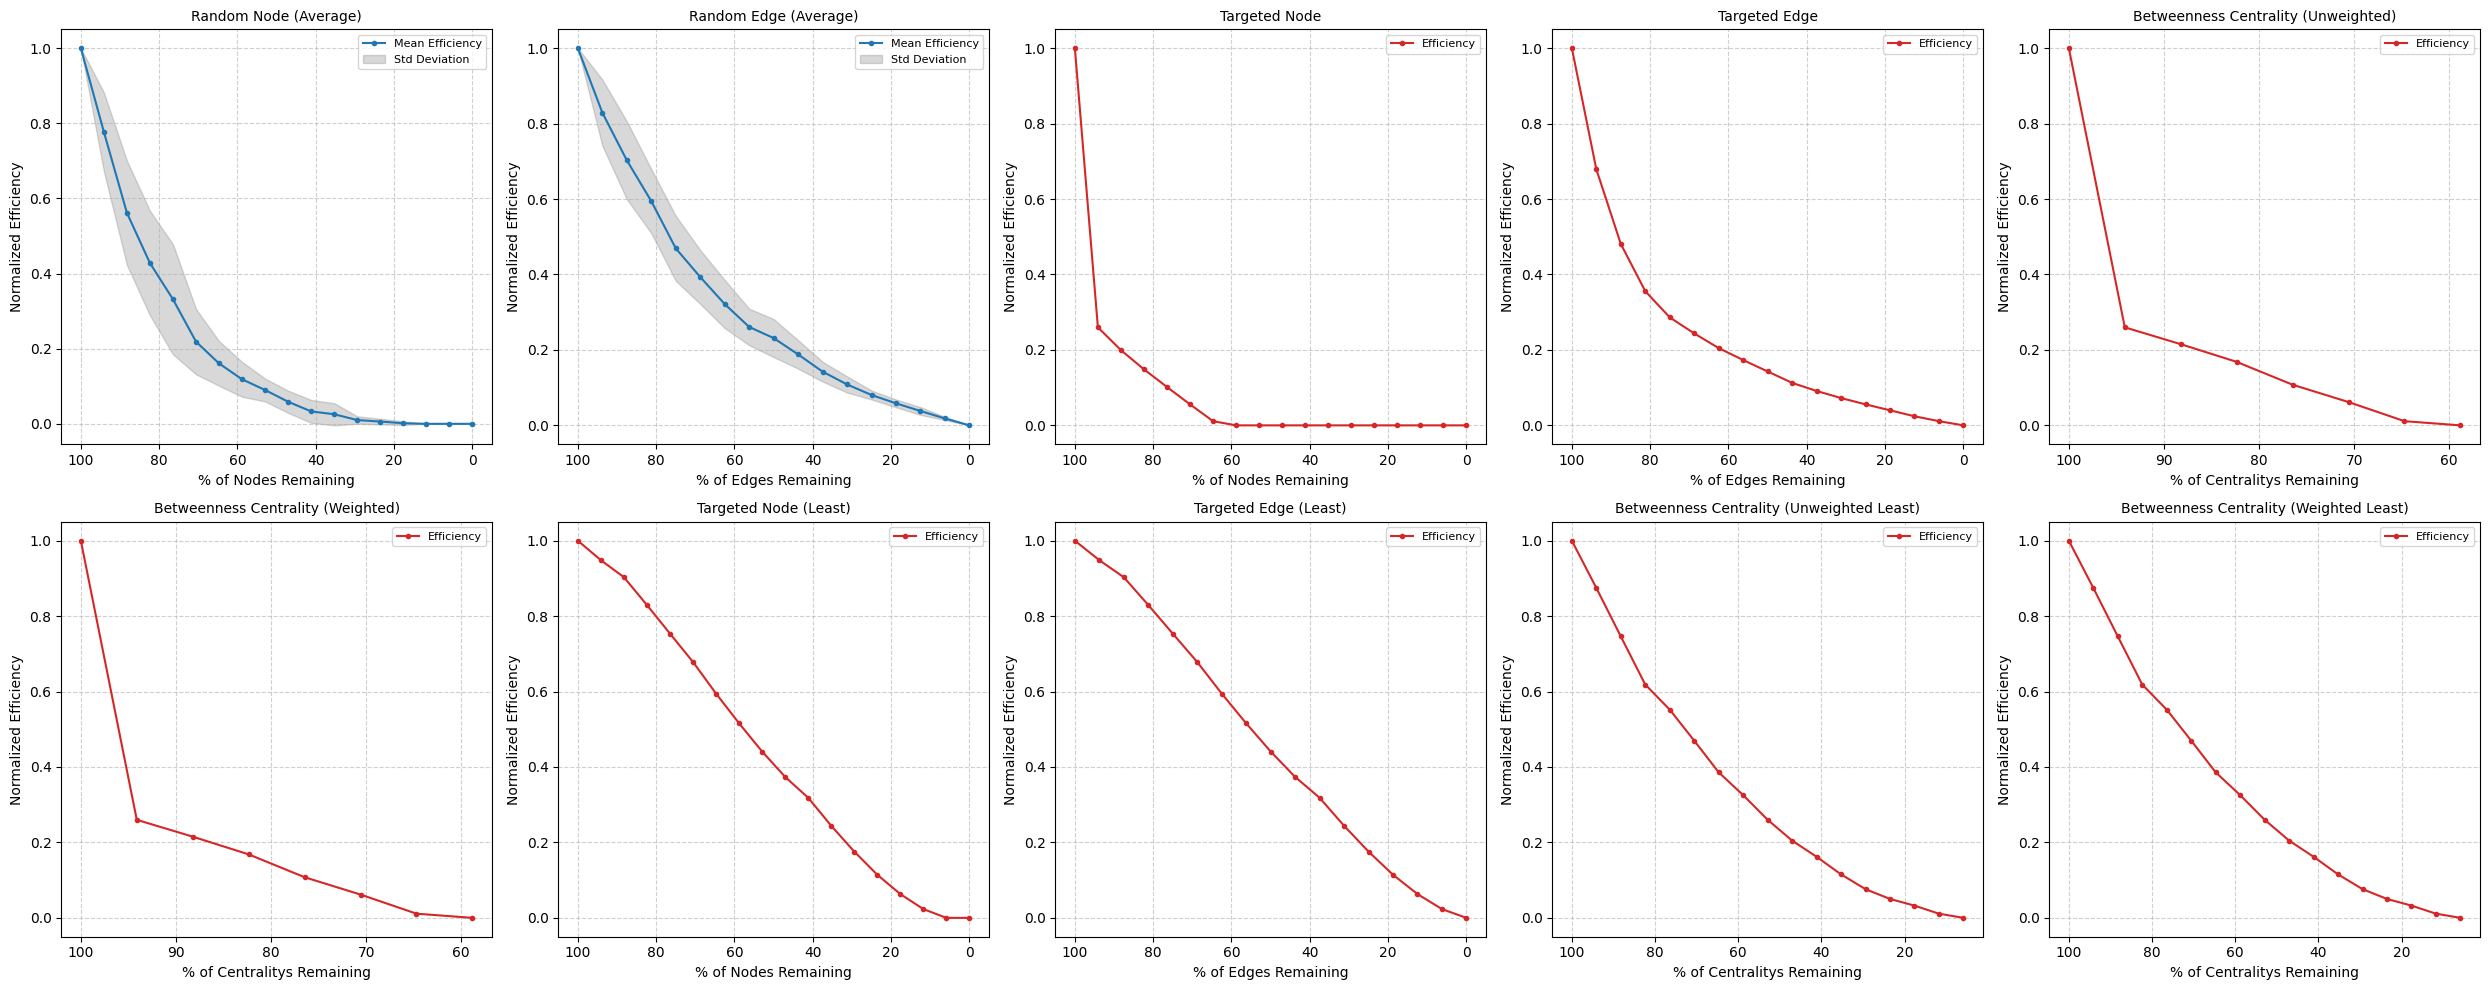

In [7]:
# Run all removal strategies and plot
results = plot_all_removal_strategies(
    subgraph=subgraph,                  # your networkx graph
    attributes=attributes,              # attributes needed for sp_func
    get_all_GTC_v4=get_all_GTC_v4,     # function for generating graph topology
    P_space_v4=P_space_v4,              # additional data needed by sp_func
    n_runs=10                            # number of runs for random average methods
)


In [8]:
subgraph = load_graph(DATA_DIR / "pkl" / "belgium" / "patterns" / "triplering" / "graph_1.pkl")
# plot_graph(subgraph, back_map="OSM")

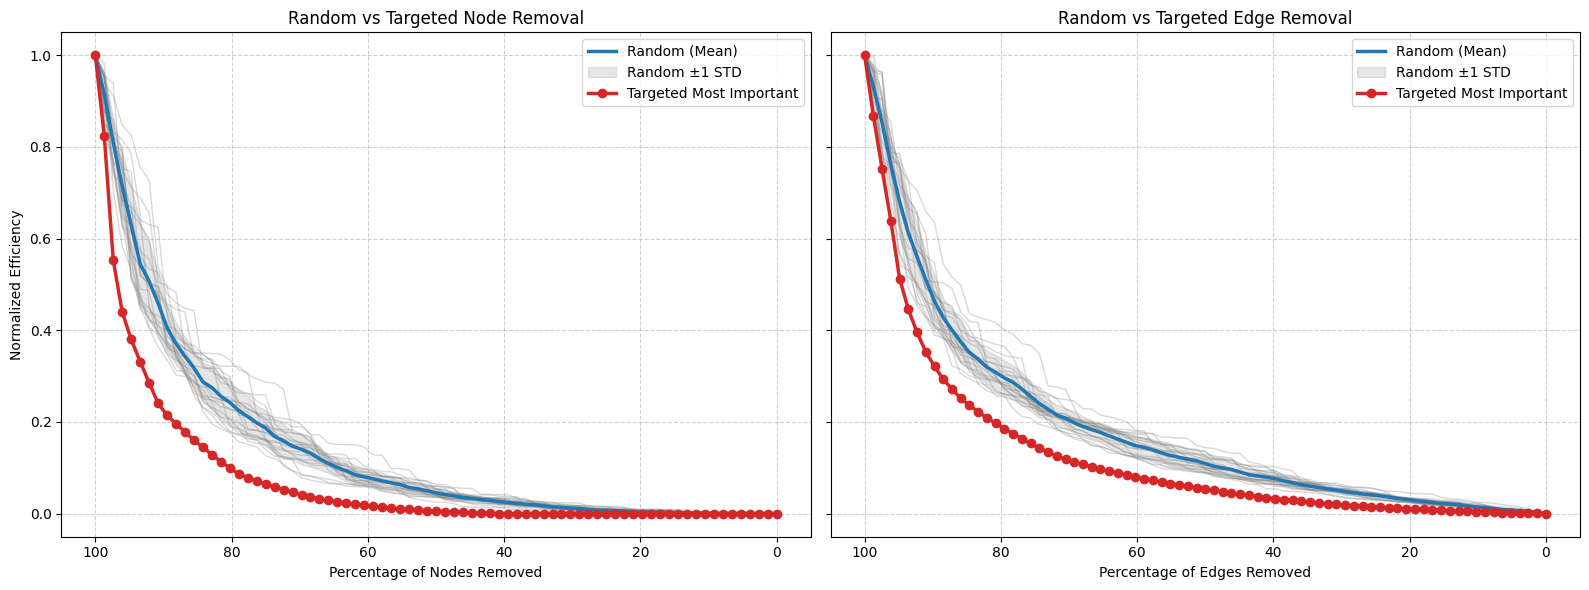

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import copy

# Parameters
n_runs = 20
base_seed = 42
sp_func = make_sp_func(attributes, get_all_GTC_v4, P_space_v4)

# Prepare figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
types = ["node", "edge"]

# Dictionary to store results inline
results = {"node": {}, "edge": {}}

for idx, rtype in enumerate(types):
    ax = axes[idx]

    # Select correct functions and total counts
    if rtype == "node":
        random_removal_func = random_node_removal
        targeted_removal_func = targeted_node_removal
        total_items = subgraph.number_of_nodes()
    else:
        random_removal_func = random_edge_removal
        targeted_removal_func = targeted_edge_removal
        total_items = subgraph.number_of_edges()

    # ---- Targeted Most Important ----
    _, eff_targeted, _, _, _ = targeted_removal_func(
        g=subgraph,
        G=copy.deepcopy(subgraph),
        num_to_remove=total_items,
        sp_func=sp_func,
        verbose=False
    )
    eff_targeted = np.array(eff_targeted, dtype=float)
    pct_targeted = 100 * (1 - np.arange(len(eff_targeted)) / total_items)
    results[rtype]["Targeted Most Important"] = (pct_targeted, eff_targeted)

    # ---- Random Removal Runs ----
    all_eff = []
    target_len = total_items + 1
    for i in range(n_runs):
        seed = base_seed + i
        _, eff, _, _, _ = random_removal_func(
            g=subgraph,
            G=copy.deepcopy(subgraph),
            num_to_remove=total_items,
            sp_func=sp_func,
            seed=seed,
            verbose=False
        )
        eff = np.array(eff, dtype=float)
        if len(eff) < target_len:
            eff = np.pad(eff, (0, target_len - len(eff)), mode='edge')
        elif len(eff) > target_len:
            eff = eff[:target_len]
        all_eff.append(eff)

    # Compute mean/std for random
    all_eff = np.vstack(all_eff)
    mean_eff = np.mean(all_eff, axis=0)
    std_eff = np.std(all_eff, axis=0)
    pct = 100 * (1 - np.arange(target_len) / total_items)
    results[rtype]["Random (Average)"] = (pct, mean_eff, std_eff)

    # ---- Plot ----
    for i in range(n_runs):
        ax.plot(pct, all_eff[i], color='gray', alpha=0.3, linewidth=1)

    ax.plot(pct, mean_eff, color='tab:blue', linewidth=2.5, label='Random (Mean)')
    ax.fill_between(pct, mean_eff - std_eff, mean_eff + std_eff,
                    color='gray', alpha=0.2, label='Random ±1 STD')

    ax.plot(pct_targeted, eff_targeted, color='tab:red', linewidth=2.5,
            marker='o', label='Targeted Most Important')

    # Styling
    ax.set_xlabel(f"Percentage of {rtype.capitalize()}s Removed")
    if idx == 0:
        ax.set_ylabel("Normalized Efficiency")
    ax.set_title(f"Random vs Targeted {rtype.capitalize()} Removal")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()
    ax.invert_xaxis()

plt.tight_layout()
plt.show()


In [10]:
subgraph = load_graph(DATA_DIR / "pkl" / "belgium" / "patterns" / "star" / "graph_0.pkl")
# plot_graph(subgraph, back_map="OSM")


=== Running NODE REMOVALS ===

--- Random (Average) ---
Function 'random_node_removal_average' completed.
Execution time: 2.30 seconds


--- Targeted Most Important ---
Function 'simulate_fixed_node_removal_efficiency' completed.
Execution time: 1.60 seconds


--- Targeted Least Important ---
Function 'simulate_fixed_node_removal_efficiency' completed.
Execution time: 4.67 seconds


=== Running EDGE REMOVALS ===

--- Random (Average) ---
Function 'random_edge_removal_average' completed.
Execution time: 3.37 seconds


--- Targeted Most Important ---
Function 'simulate_fixed_node_removal_efficiency' completed.
Execution time: 3.98 seconds


--- Targeted Least Important ---
Function 'simulate_fixed_node_removal_efficiency' completed.
Execution time: 4.94 seconds



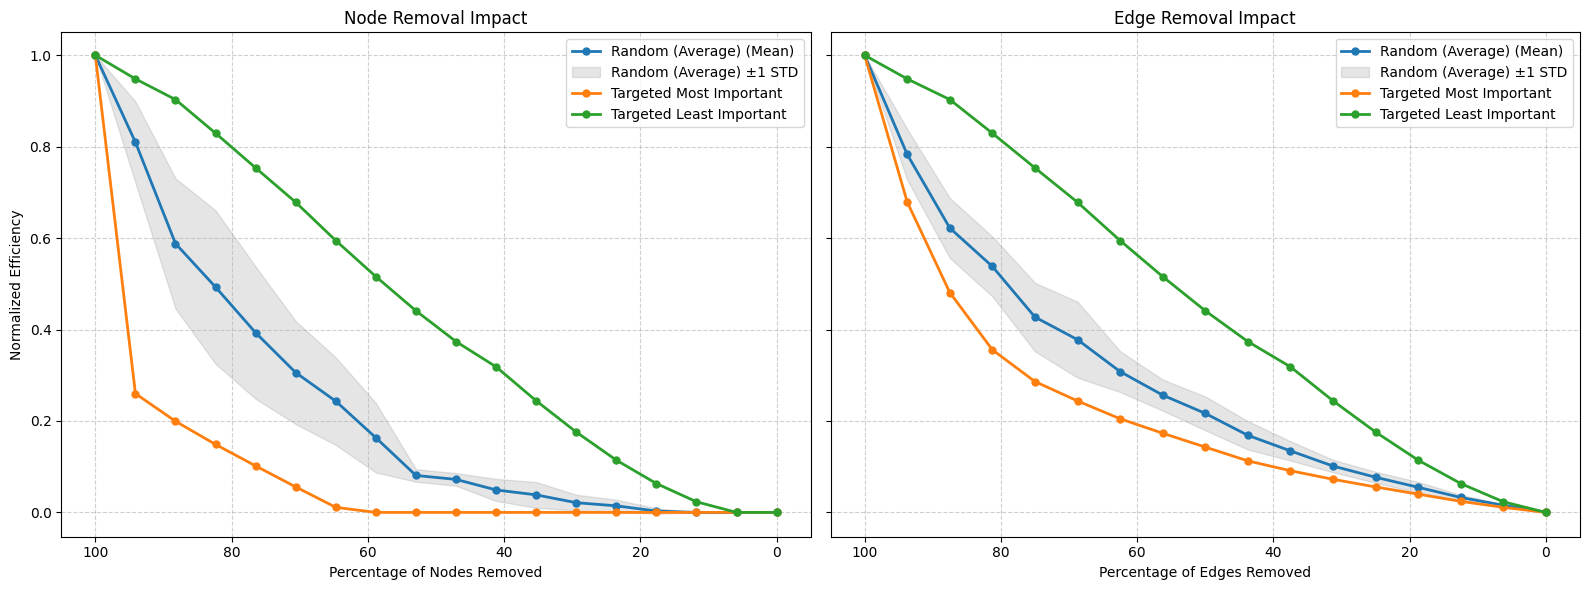

In [11]:
import matplotlib.pyplot as plt

# Define methods to compare
methods = {
    "Random (Average)": "random_average",
    "Targeted Most Important": "targeted",
    "Targeted Least Important": "targeted_least"
}

# Define removal types
removal_types = ["node", "edge"]

# Prepare storage for all results
results = {rtype: {} for rtype in removal_types}

# Shared shortest-path function
sp_func = make_sp_func(attributes, get_all_GTC_v4, P_space_v4)

# Main loop: iterate over removal types and methods
for rtype in removal_types:
    print(f"\n=== Running {rtype.upper()} REMOVALS ===")
    for label, method in methods.items():
        print(f"\n--- {label} ---")

        if method == "random_average":
            # Use the modified function for random average
            if rtype == "node":
                orig_eff, mean_eff, std_eff, pct = random_node_removal_average(
                    L_graph=subgraph,
                    G=subgraph.copy(),
                    num_to_remove=subgraph.number_of_nodes(),
                    sp_func=sp_func,
                    n_runs=10,
                    verbose=False
                )
            else:  # edge removal
                orig_eff, mean_eff, std_eff, pct = random_edge_removal_average(
                    L_graph=subgraph,
                    G=subgraph.copy(),
                    num_to_remove=subgraph.number_of_edges(),
                    sp_func=sp_func,
                    n_runs=10,
                    verbose=False
                )

            results[rtype][label] = (pct, mean_eff, std_eff)

        else:
            # Standard single-run simulation
            original_eff, effs, pct, removed, times = simulate_fixed_node_removal_efficiency(
                L_graph=subgraph,
                sp_func=sp_func,
                pct_to_remove=100,
                removal_type=rtype,
                method=method,
                seed=42,
                verbose=False
            )
            results[rtype][label] = (pct, effs)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for i, rtype in enumerate(removal_types):
    ax = axes[i]
    for label, data in results[rtype].items():
        if label == "Random (Average)":
            pct, mean_eff, std_eff = data
            ax.plot(pct, mean_eff, marker='o', label=f"{label} (Mean)", linewidth=2, markersize=5)
            ax.fill_between(pct, mean_eff - std_eff, mean_eff + std_eff,
                            color='gray', alpha=0.2, label=f"{label} ±1 STD")
        else:
            pct, effs = data
            ax.plot(pct, effs, marker='o', label=label, linewidth=2, markersize=5)

    ax.set_xlabel(f"Percentage of {rtype.capitalize()}s Removed")
    ax.set_title(f"{rtype.capitalize()} Removal Impact")
    ax.invert_xaxis()
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

axes[0].set_ylabel("Normalized Efficiency")
plt.tight_layout()
plt.show()
